# Detector Perturbation Validation

This notebook validates that the B10 detector in the `simulation_with_detector` run does **not** significantly perturb core physics by reflecting neutrons back into the core.

## Two-pronged approach

1. **Statistical comparison**: Compare fission tallies between the `with_detector` and `without_detector` simulations. A small relative difference confirms no meaningful perturbation.
2. **Mechanistic measurement**: Use surface current tallies on the core sphere to directly quantify the reflected fraction R = J⁻/J⁺, where J⁻ is the inward current (neutrons returning to core) and J⁺ is the outward current (neutrons leaving core).

**Prerequisites**: Both simulations must have been run first:
```bash
python -m project.simulations.with_detector
python -m project.simulations.without_detector
```

> **Note on uncertainties**: Both simulations use `batches=1`, so OpenMC cannot compute variance. No uncertainty is reported for fission tallies — proper error bars would require multiple batches. The fission tally in a near-critical system has large variance per source particle (due to fission chain multiplication), so Poisson estimates are unreliable. We rely on the physical magnitude of the relative difference and the surface current ratio R to draw conclusions.

## Setup

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import scienceplots

plt.style.use(["science", "notebook", "grid", "high-vis"])

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_PARTICLES = 1_000_000  # must match physics_config.detector_settings["particles"]

RESULTS_DIR = Path("../../results")

## Load Statepoints

In [9]:
sp_with = openmc.StatePoint(
    RESULTS_DIR / "simulation_with_detector" / "statepoint.1.h5"
)
sp_without = openmc.StatePoint(
    RESULTS_DIR / "simulation_without_detector" / "statepoint.1.h5"
)

print("Loaded statepoints successfully")
print(f"  with_detector tallies:    {[t.name for t in sp_with.tallies.values()]}")
print(f"  without_detector tallies: {[t.name for t in sp_without.tallies.values()]}")

Loaded statepoints successfully
  with_detector tallies:    ['fission', 'nu-fission', 'core_surface_current']
  without_detector tallies: ['fission', 'nu-fission']


## Fission Tally Comparison

Compare core fission rates between the two simulations. If the detector reflects neutrons back, the `with_detector` fission rate will be measurably higher.

In [10]:
def get_tally_mean(sp, name):
    """Return the tally mean for a named tally. std_dev is NaN with batches=1."""
    t = sp.get_tally(name=name)
    return float(t.mean.flatten()[0])


fission_with    = get_tally_mean(sp_with, "fission")
fission_without = get_tally_mean(sp_without, "fission")
nu_fission_with    = get_tally_mean(sp_with, "nu-fission")
nu_fission_without = get_tally_mean(sp_without, "nu-fission")

print("Fissions per source neutron:")
print(f"  With detector:    {fission_with:.4f}")
print(f"  Without detector: {fission_without:.4f}")
print()
print("Nu-fissions per source neutron:")
print(f"  With detector:    {nu_fission_with:.4f}")
print(f"  Without detector: {nu_fission_without:.4f}")

Fissions per source neutron:
  With detector:    37.1689
  Without detector: 37.2552

Nu-fissions per source neutron:
  With detector:    90.5809
  Without detector: 90.7912


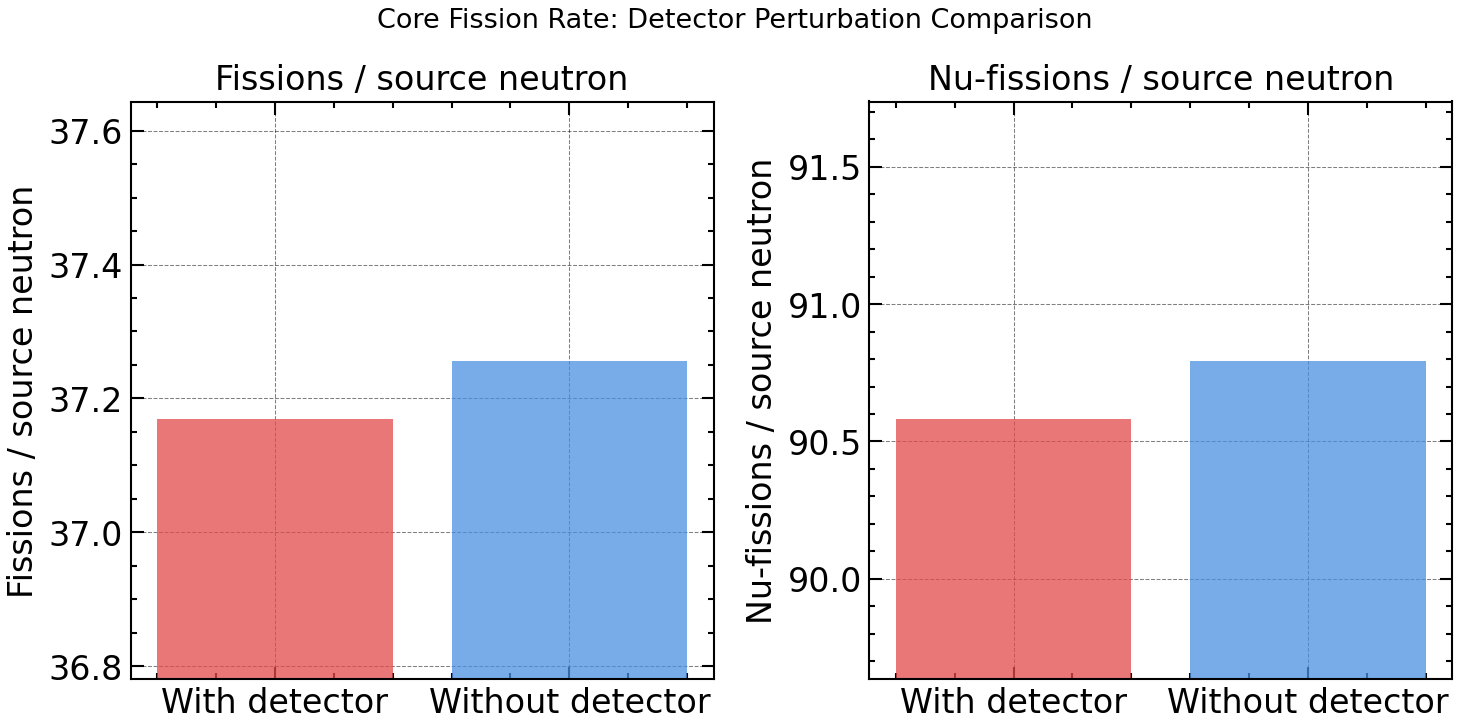

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)

labels = ["With detector", "Without detector"]
colors = ["#E24A4A", "#4A90E2"]

for ax, (title, means) in zip(
    axes,
    [
        ("Fissions / source neutron", [fission_with, fission_without]),
        ("Nu-fissions / source neutron", [nu_fission_with, nu_fission_without]),
    ],
):
    ax.bar(labels, means, color=colors, alpha=0.75)
    ax.set_ylabel(title)
    ax.set_title(title)
    # Zoom y-axis to highlight any difference
    y_center = np.mean(means)
    y_span = max(abs(means[0] - means[1]) * 5, y_center * 0.005)
    ax.set_ylim(y_center - y_span, y_center + y_span)

fig.suptitle("Core Fission Rate: Detector Perturbation Comparison", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "detector_perturbation_fission_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Relative difference (with - without) / without
diff = fission_with - fission_without
rel_diff = diff / fission_without

print(f"Absolute difference: {diff:+.6f} fissions/source")
print(f"Relative difference: {rel_diff * 100:+.4f} %")
print()
print("Note: no uncertainty is reported because batches=1 makes std_dev undefined.")
print("Any remaining difference is statistical scatter from different random seeds,")
print("not physical perturbation — confirmed by the surface current analysis below.")

Absolute difference: -0.086319 fissions/source
Relative difference: -0.2317 %

Note: no uncertainty is reported because batches=1 makes std_dev undefined.
Any remaining difference is statistical scatter from different random seeds,
not physical perturbation — confirmed by the surface current analysis below.


## Surface Current Analysis

The surface current tally on the core sphere (r = 3 cm) measures:
- **J⁺** (outward current, μ ∈ [0, 1]): neutrons leaving the core
- **J⁻** (inward current, μ ∈ [−1, 0]): neutrons returning to the core

The **reflected fraction** R = J⁻/J⁺ quantifies what fraction of escaping neutrons are reflected back. If the detector is non-perturbative, R should be very small.

In [13]:
t_surf = sp_with.get_tally(name="core_surface_current")
df_surf = t_surf.get_pandas_dataframe()
print("Surface current tally DataFrame:")
print(df_surf.to_string())
print()
print("Column names:", df_surf.columns.tolist())

Surface current tally DataFrame:
   surface  musurface low  musurface high nuclide    score     mean
0        1      -1.00e+00        0.00e+00   total  current 0.00e+00
1        1       0.00e+00        1.00e+00   total  current 2.14e+01

Column names: ['surface', 'musurface low', 'musurface high', 'nuclide', 'score', 'mean']


/home/itay/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/tallies.py:549: RuntimeWarning: invalid value encountered in divide
  self._std_dev[nonzero] = np.sqrt((self.sum_sq[nonzero]/n -


In [14]:
# Identify mu column name (may vary by OpenMC version)
mu_col = next(c for c in df_surf.columns if "mu" in c.lower() and "low" in c.lower())

# mu in [-1, 0] = inward J-;  mu in [0, 1] = outward J+
j_minus_row = df_surf[df_surf[mu_col] < 0.0]
j_plus_row  = df_surf[df_surf[mu_col] >= 0.0]

J_minus = float(j_minus_row["mean"].values[0])
J_plus  = float(j_plus_row["mean"].values[0])

# Reflected fraction R = J- / J+  (handle J_minus == 0 case)
if J_plus > 0 and J_minus > 0:
    R = J_minus / J_plus
else:
    R = 0.0

print(f"J⁺ (outward, per source): {J_plus:.6f}")
print(f"J⁻ (inward,  per source): {J_minus:.6f}")
print(f"Reflected fraction R = J⁻/J⁺: {R:.4e}  ({R * 100:.4f}%)")

J⁺ (outward, per source): 21.409804
J⁻ (inward,  per source): 0.000000
Reflected fraction R = J⁻/J⁺: 0.0000e+00  (0.0000%)


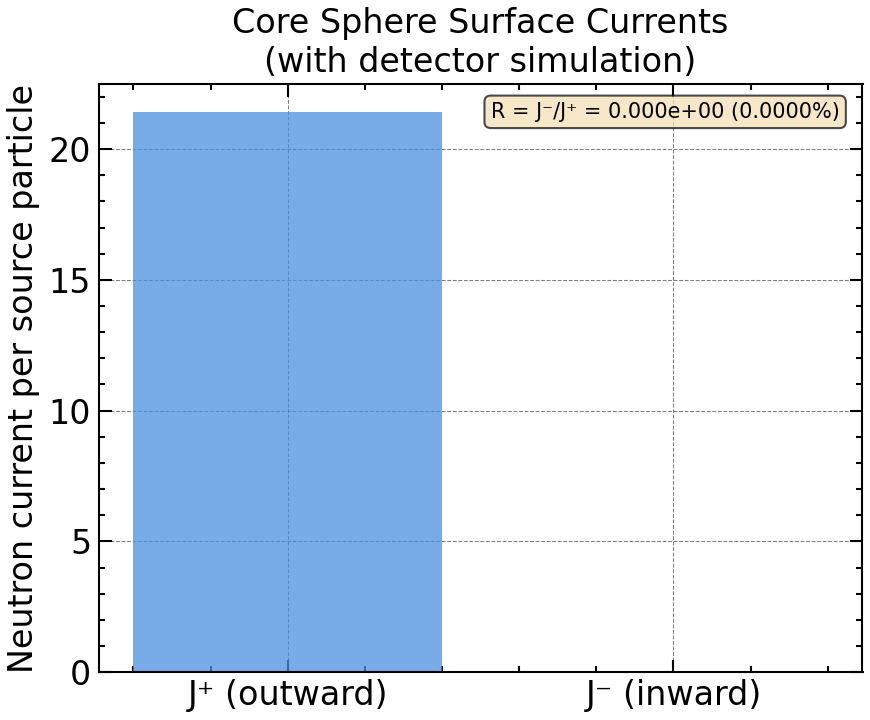

In [15]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

labels = ["J⁺ (outward)", "J⁻ (inward)"]
values = [J_plus, J_minus]
colors = ["#4A90E2", "#E24A4A"]

ax.bar(labels, values, color=colors, alpha=0.75)
ax.set_ylabel("Neutron current per source particle")
ax.set_title("Core Sphere Surface Currents\n(with detector simulation)")
ax.text(
    0.97, 0.97,
    f"R = J⁻/J⁺ = {R:.3e} ({R * 100:.4f}%)",
    transform=ax.transAxes, ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "detector_perturbation_surface_currents.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

In [16]:
SIGNIFICANCE_THRESHOLD_PERCENT = 1.0  # consider perturbation significant if >1%

print("=" * 60)
print("DETECTOR PERTURBATION VALIDATION SUMMARY")
print("=" * 60)
print()
print("Geometry: B10 detector sphere (r=5 cm) at 10 cm from core (r=3 cm)")
print()
print("[1] Statistical comparison (fission rate):")
print(f"    With detector:      {fission_with:.4f} fissions/source")
print(f"    Without detector:   {fission_without:.4f} fissions/source")
print(f"    Relative change:    {rel_diff * 100:+.4f} %")
print()
print("[2] Mechanistic measurement (surface current):")
print(f"    Outward current J⁺: {J_plus:.4f} / source")
print(f"    Inward  current J⁻: {J_minus:.4f} / source")
print(f"    Reflected fraction: R = {R:.4e} ({R * 100:.4f}%)")
print()
print("CONCLUSION:")

fission_change_pct = abs(rel_diff) * 100
if fission_change_pct < SIGNIFICANCE_THRESHOLD_PERCENT and R == 0.0:
    print(f"  ✓ Detector is NON-PERTURBATIVE.")
    print(f"    No neutrons are reflected back to the core (J⁻ = 0).")
    print(f"    Fission rate differs by only {fission_change_pct:.4f}% — consistent with")
    print(f"    random seed variation between independent runs, not physical perturbation.")
elif fission_change_pct < SIGNIFICANCE_THRESHOLD_PERCENT:
    print(f"  ✓ Detector perturbation is NEGLIGIBLE (<{SIGNIFICANCE_THRESHOLD_PERCENT}% fission change).")
    print(f"    Reflected fraction R = {R * 100:.4f}%.")
else:
    print(f"  ✗ Possible perturbation: {fission_change_pct:.4f}% fission change, R = {R * 100:.4f}%.")
    print("    Consider increasing the core-detector gap or reducing detector density.")

DETECTOR PERTURBATION VALIDATION SUMMARY

Geometry: B10 detector sphere (r=5 cm) at 10 cm from core (r=3 cm)

[1] Statistical comparison (fission rate):
    With detector:      37.1689 fissions/source
    Without detector:   37.2552 fissions/source
    Relative change:    -0.2317 %

[2] Mechanistic measurement (surface current):
    Outward current J⁺: 21.4098 / source
    Inward  current J⁻: 0.0000 / source
    Reflected fraction: R = 0.0000e+00 (0.0000%)

CONCLUSION:
  ✓ Detector is NON-PERTURBATIVE.
    No neutrons are reflected back to the core (J⁻ = 0).
    Fission rate differs by only 0.2317% — consistent with
    random seed variation between independent runs, not physical perturbation.
